# Image Classification
___
#### Import Library and Load Trained Model

In [39]:
#Library Import
import pickle
import tensorflow as tf
import PIL
from PIL import Image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dropout, Dense, Softmax)
from tensorflow.keras.applications import mobilenet as _mobilenet
import random
import os
import numpy as np
from subprocess import call
import scipy
import matplotlib.pyplot as plt
from matplotlib import cm
import math
from decimal import Decimal, localcontext
from pathlib import Path
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the saved model from the "Pickle" folder
model = load_model('Pickle/trained_model.h5')

# Now you can use the model for predictions, evaluation, or further training

def opF(path):
    p = Path(path)
    os.startfile(p) # for Windows
    #_ = call(['open',p]) # for Mac/Linux

#### Load History and Classes

[0.49912697076797485, 0.35495108366012573, 0.1906125396490097, 0.15624506771564484, 0.14865031838417053, 0.12530310451984406, 0.0976724699139595, 0.0629926323890686, 0.0955934002995491, 0.2745515704154968, 0.19217318296432495, 0.1343911588191986, 0.09075124561786652, 0.0515139102935791, 0.03852672502398491, 0.08371683210134506, 0.05915646627545357, 0.06104578450322151, 0.15486136078834534, 0.10075972229242325]
[5.841088771820068, 2.5413429737091064, 0.4517779052257538, 0.13861224055290222, 0.41339606046676636, 1.2182565927505493, 0.4614911377429962, 0.9561763405799866, 1.6822763681411743, 0.7759378552436829, 2.5662026405334473, 0.37162870168685913, 0.44460684061050415, 0.3241128623485565, 0.19204871356487274, 0.490908682346344, 0.13593070209026337, 0.2933957278728485, 0.23735173046588898, 0.16603928804397583]


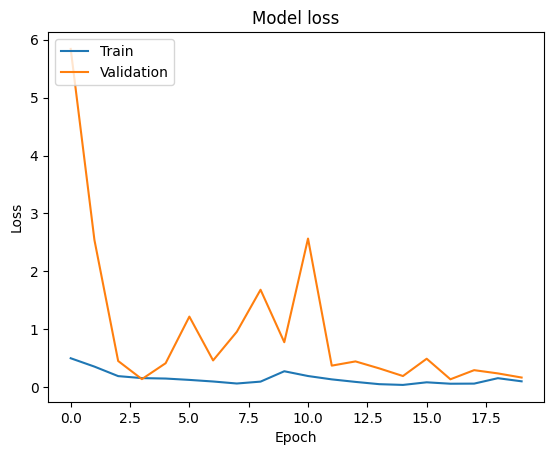

{'Fossil': 0, 'Pattern': 1, 'Place in Athens': 2, 'Pottery': 3, 'Sculpture': 4}


In [4]:
# Load the history object from the pickle file
with open('Pickle/history.pkl', 'rb') as f:
    loaded_history = pickle.load(f)
# Access the loss and accuracy data
print(loaded_history['loss'])
print(loaded_history['val_loss'])

# Now the loaded_history will have the same structure as the original history
plt.plot(loaded_history['loss'])
plt.plot(loaded_history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Load class indices from pickle file
with open('Pickle/class_indices.pkl', 'rb') as f:
    class_indices = pickle.load(f)
    
print(class_indices)

#### Testing

In [5]:
def load_image(img_file, target_size=(224,224)):
    X = np.zeros((1, *target_size, 3))
    X[0, ] = np.asarray(tf.keras.preprocessing.image.load_img(
        img_file, 
        target_size=target_size)
    )
    X = tf.keras.applications.mobilenet.preprocess_input(X)
    return X

def ensure_folder_exists(folder):
    if not os.path.exists(folder):
        os.makedirs(folder)

In [6]:
random_item = random.choice(os.listdir(r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_Thesis_Project\JPG"))
item_path = os.path.join(r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_Thesis_Project\JPG",random_item)
item = load_image(item_path)

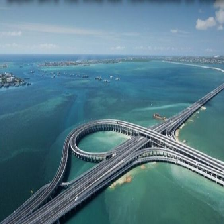

In [7]:
tf.keras.preprocessing.image.load_img(item_path, target_size=(224,224))

In [8]:
print(f'''Relation to: \nFossil:Pattern:Place in Athens:Pottery:Sculpture\n{np.round(model.predict(item),2)}''')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
Relation to: 
Fossil:Pattern:Place in Athens:Pottery:Sculpture
[[0.33 0.06 0.25 0.27 0.09]]


## Sorting Testing Images to Classes
___

In [23]:
image_folder = r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop2\Testing Images"

1. Fossil Class = predictions[0][0]
2. Pattern Class = predictions[0][1]
3. Place in Athens Class = predictions[0][2]
4. Pottery Class = predictions[0][3]
5. Sculpture Class = predictions[0][4]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━

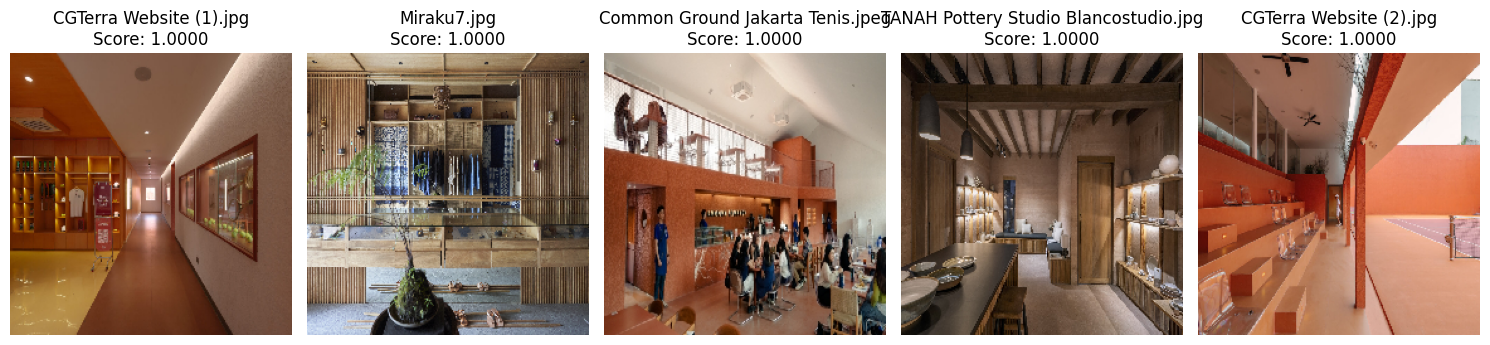

In [31]:
#Create a list to store the filenames
image_scores = []

#Loop through each image file in the folder
for img_filename in os.listdir(image_folder):
    if img_filename.endswith(".jpg") or img_filename.endswith(".jpeg"):
        img_path = os.path.join(image_folder, img_filename)

        #Load and preprocess the image
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = tf.keras.applications.mobilenet.preprocess_input(img_array)

        #Predict the class probabilities
        predictions = model.predict(img_array)

        #'Fossil': 0, 'Pattern': 1, 'Place in Athens': 2, 'Pottery': 3, 'Sculpture': 4
        jpg_score = predictions[0][2]

        #Store the filename and score
        image_scores.append((img_filename, jpg_score, img_path))

#Sort the images based on the score (highest to lowest)
sorted_images = sorted(image_scores, key=lambda x: x[1], reverse=True)

#Print the sorted image scores with filenames
print("Sorted image scores:")
for img_filename, score, _ in sorted_images:
    print(f"{img_filename}: {score:.4f}")

#Display the top 5 images closest to chosen class
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i in range(5):
    img_filename, score, img_path = sorted_images[i]
    
    # Load the image for display
    img = image.load_img(img_path, target_size=(224, 224))
    
    # Display the image and its score
    axes[i].imshow(img)
    axes[i].axis('off') 
    axes[i].set_title(f"{img_filename}\nScore: {score:.4f}")

plt.tight_layout()
plt.show()

### Top Image of each Classes
___

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
IMG_2725.jpg: [0. 1. 0. 0. 0.]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Miraku6.jpg: [0.01 0.8  0.09 0.02 0.08]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1 of 7 Vintage Wedgwood Home Aztec Dinner Plates 10 1_2in Diameter Excellent E.jpg: [0.   0.   0.   0.99 0.01]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
dsc08712.JPG: [0. 0. 1. 0. 0.]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
dsc08758.JPG: [0.   0.3  0.06 0.24 0.4 ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
UVP.jpg: [0.49 0.01 0.51 0.   0.  ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
!!!!! ANTIQUE FAIENCE TILES CERAMIC TILE!!!!!.jpg: [0. 0. 1. 0. 0.]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Capitol.jpg: [0.   0.99 0.   0.   0.  ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
dsc08713.JPG: [0.   0.17 0.82 0.   0.01]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1 of 7 Vintage Wedgwood Home Aztec Dinner Plates 10 1_2in Diameter Excellent E.jpg: [0.   0.   0.   0.99 0.01]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
IMG_2636.jpg: [0. 1. 0. 0. 0.]
1

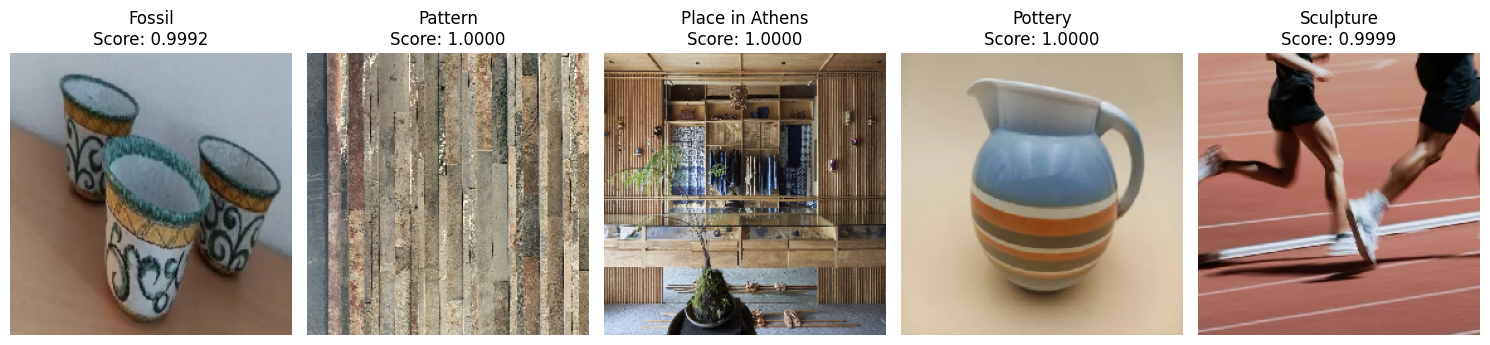

In [35]:
#Specify the path to your image folder
image_folder = r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop2\Testing Images"

#Define the classes based on your model output
classes = ['Fossil', 'Pattern', 'Place in Athens', 'Pottery', 'Sculpture']

#Initialize a dictionary to store the top image and score for each class
top_images = {class_name: {'image': None, 'score': -1} for class_name in classes}

#Function to check if a file is a .jpg image
def is_jpg(file_name):
    return file_name.lower().endswith('.jpg') or file_name.lower().endswith('.jpeg')

#Number of images to predict
num_images_to_predict = 200
predictions = []  # List to store predictions

for _ in range(num_images_to_predict):
    #Get a random file from the folder
    jpg_images = [item for item in os.listdir(image_folder) if is_jpg(item)]
    if not jpg_images:
        print("No jpg images found in the folder.")
        break
    
    img_filename = random.choice(jpg_images)
    img_path = os.path.join(image_folder, img_filename)
    
    #Load and preprocess the image
    try:
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = tf.keras.applications.mobilenet.preprocess_input(img_array)

        #Predict using the model
        prediction = model.predict(img_array)[0]  # Get the prediction for this image

        #Store the prediction
        predictions.append(prediction)

        #Update the top image for each class based on the score
        for idx, class_name in enumerate(classes):
            if prediction[idx] > top_images[class_name]['score']:
                top_images[class_name] = {'image': img, 'score': prediction[idx]}
        
        print(f"{img_filename}: {np.round(prediction, 2)}")
    
    except Exception as e:
        print(f"Error processing image {img_filename}: {e}")

#Calculate the average prediction scores across all classes, ensuring no empty predictions
if predictions:
    predictions_array = np.array(predictions)  # Convert the list of predictions to a numpy array
    average_prediction = np.mean(predictions_array, axis=0)  # Calculate the average across all images

    # Print the average prediction scores for each class
    for idx, class_name in enumerate(classes):
        print(f"Average score for class '{class_name}': {average_prediction[idx]:.4f}")
else:
    print("No predictions to calculate averages.")

#Display the top image for each class
fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))

for i, class_name in enumerate(classes):
    axes[i].imshow(top_images[class_name]['image'])
    axes[i].axis('off')
    axes[i].set_title(f"{class_name}\nScore: {top_images[class_name]['score']:.4f}")

plt.tight_layout()
plt.show()

#### Top 5 Images to Inserted Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━

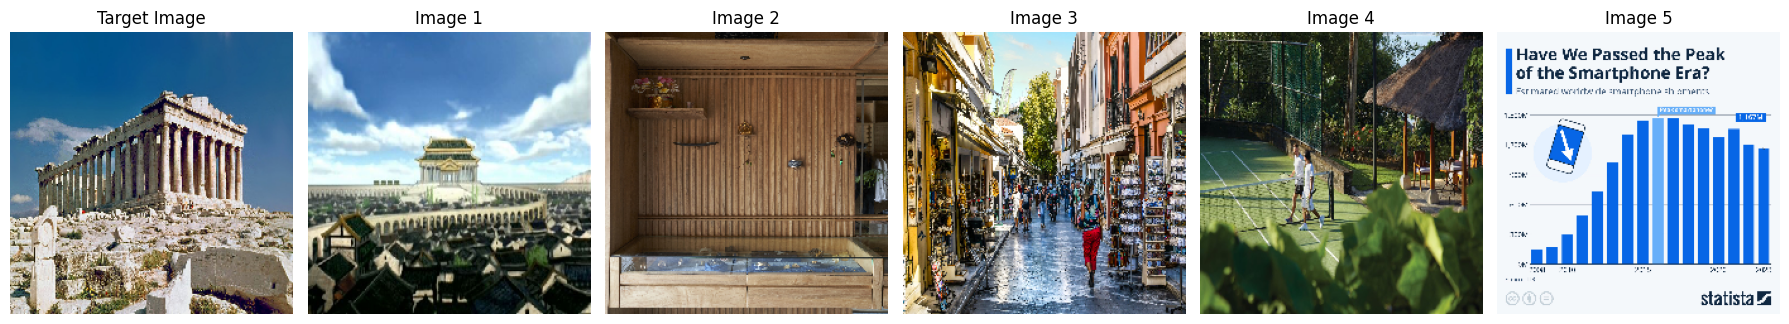

Target Image: E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop2\Parthenon.jpg

Top 5 closest images to the target image:
1. Ba Sing Se.jpg - Distance: 0.0037
2. Miraku10.jpg - Distance: 0.0042
3. Athens Market.jpg - Distance: 0.0049
4. Four Seasons Bali Resort.jpg - Distance: 0.0057
5. Smartphone.jpeg - Distance: 0.0060


In [37]:
#Define the classes based on your model output
classes = ['Fossil', 'Pattern', 'Place in Athens', 'Pottery', 'Sculpture']

#Function to check if a file is a .jpg image
def is_jpg(file_name):
    return file_name.lower().endswith('.jpg') or file_name.lower().endswith('.jpeg')

#Function to get the model prediction score for a given image
def get_image_score(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet.preprocess_input(img_array)
    
    prediction = model.predict(img_array)[0]  # Get the prediction for this image
    return prediction

#Scoring target image
target_image_path = r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop2\Parthenon.jpg"
target_image_score = get_image_score(target_image_path)

#Scoring all image in image_folder
image_scores = []
for img_filename in os.listdir(image_folder):
    if is_jpg(img_filename):
        img_path = os.path.join(image_folder, img_filename)
        
        #Get the prediction score for the image
        img_score = get_image_score(img_path)
        
        #Store the filename and its score
        image_scores.append((img_filename, img_score, img_path))

#Calculate the Euclidean distance
distances = []
for img_filename, img_score, img_path in image_scores:
    #Calculate Euclidean distance between target image score and current image score
    distance = np.linalg.norm(target_image_score - img_score)
    distances.append((img_filename, distance, img_path))

#Sort the images by their distance
sorted_images = sorted(distances, key=lambda x: x[1])
top_5_images = sorted_images[:5]

#Display the top 5 closest images
fig, axes = plt.subplots(1, 6, figsize=(18, 6))  # 1 row, 6 columns for target + 5 closest images

#Display the target image
target_img = image.load_img(target_image_path, target_size=(224, 224))
axes[0].imshow(target_img)
axes[0].axis('off')
axes[0].set_title("Target Image")

#Display the top 5 closest images
for i, (img_filename, _, img_path) in enumerate(top_5_images):
    img = image.load_img(img_path, target_size=(224, 224))
    
    axes[i + 1].imshow(img)
    axes[i + 1].axis('off')
    axes[i + 1].set_title(f"Image {i + 1}")

plt.tight_layout()
plt.show()

#Optionally, print the file names and distances of the top 5 closest images
print(f"Target Image: {target_image_path}")
print("\nTop 5 closest images to the target image:")
for i, (img_filename, distance, _) in enumerate(top_5_images):
    print(f"{i + 1}. {img_filename} - Distance: {distance:.4f}")